# Task C — Whole shelf challenge

Scenes `h1..h5` (hard, low resolution, distractor elements), products `0..23` (24 products, often multiple instances per scene).

Reuses Task B's GHT pipeline with two extras:
1. **Scene SIFT runs once per scene** and is shared across all 24 product checks (performance — otherwise we'd do 120 scene-SIFT calls instead of 5).
2. **Per-peak RANSAC homography** verification → accurate warped bbox per instance.

# Setup

In [11]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Paths and the Task C dataset
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "tasks" else Path.cwd()
MODELS_DIR = PROJECT_ROOT / "models"
SCENES_DIR = PROJECT_ROOT / "scenes"
STEP_C_SCENES   = [f"h{i}.jpg" for i in range(1, 6)]   # files are .jpg, not .png
STEP_C_PRODUCTS = [str(i) for i in range(24)]          # products 0..23

# Tunable parameters — looser than Task B because low-res scenes give noisier descriptors
LOWE_RATIO = 0.75
RANSAC_REPROJ_THRESH = 5.0
MIN_GOOD_MATCHES = 6
MIN_INLIERS = 6

# GHT parameters
VOTE_BIN_SIZE = 10
MIN_PEAK_VOTES = 5             # lower than B since each low-res instance produces fewer votes
PEAK_SUPPRESSION_RADIUS = 30   # tighter than B since shelf products are densely packed

# Task-C-specific tunables
SIFT_CONTRAST_THRESHOLD = 0.02   # default 0.04 — lower picks up weaker keypoints on low-res images

# BGR (OpenCV) -> RGB (matplotlib)
def show_bgr(bgr, title="", figsize=(12, 8)):
    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
    plt.title(title); plt.axis("off"); plt.show()

# Multi-instance detection helper

Same shape as Task B's `detect_instances` plus one extra guard: **RANSAC homography on local voters** → bbox by warping the model corners (more accurate than `model_dims × median_scale`).

In [12]:
def detect_instances(model_bgr, scene_bgr, scene_gray, kp_scene, des_scene, model_id):
    """Returns a list of detection dicts for one model in one scene."""
    if des_scene is None:
        return []

    model_gray = cv2.cvtColor(model_bgr, cv2.COLOR_BGR2GRAY)
    mh, mw = model_gray.shape

    # SIFT on the model
    sift = cv2.SIFT_create(contrastThreshold=SIFT_CONTRAST_THRESHOLD)
    kp_model, des_model = sift.detectAndCompute(model_gray, None)
    if des_model is None:
        return []

    # Model: joining vectors from each keypoint to the barycenter
    barycenter = np.array([mw / 2, mh / 2])
    joining_vectors = np.array([barycenter - kp.pt for kp in kp_model])

    # FLANN + Lowe (model vs pre-computed scene descriptors)
    matcher = cv2.FlannBasedMatcher(dict(algorithm=1, trees=5), dict(checks=50))
    knn = matcher.knnMatch(des_model, des_scene, k=2)
    good_matches = [m for m, n in knn if m.distance < LOWE_RATIO * n.distance]
    if len(good_matches) < MIN_GOOD_MATCHES:
        return []

    # Pre-compute every match's vote (x, y, scale, match) — reused for accumulator + bbox
    votes = []
    for m in good_matches:
        model_kp = kp_model[m.queryIdx]
        scene_kp = kp_scene[m.trainIdx]
        scale = scene_kp.size / model_kp.size
        v = joining_vectors[m.queryIdx] * scale
        votes.append((scene_kp.pt[0] + v[0], scene_kp.pt[1] + v[1], scale, m))

    # GHT accumulator
    scene_h, scene_w = scene_gray.shape
    acc_h = scene_h // VOTE_BIN_SIZE + 1
    acc_w = scene_w // VOTE_BIN_SIZE + 1
    accumulator = np.zeros((acc_h, acc_w), dtype=np.float32)
    for vx, vy, _, _ in votes:
        bx, by = int(vx // VOTE_BIN_SIZE), int(vy // VOTE_BIN_SIZE)
        if 0 <= bx < acc_w and 0 <= by < acc_h:
            accumulator[by, bx] += 1

    # Peak detection (cv2.dilate = max filter; local max where original == dilated)
    neighborhood = max(1, PEAK_SUPPRESSION_RADIUS // VOTE_BIN_SIZE)
    kernel = np.ones((neighborhood, neighborhood), np.uint8)
    is_peak = (accumulator == cv2.dilate(accumulator, kernel)) & (accumulator >= MIN_PEAK_VOTES)
    peak_ys, peak_xs = np.where(is_peak)

    # Per-peak: RANSAC homography → warped bbox
    detections = []
    r2 = PEAK_SUPPRESSION_RADIUS ** 2

    for bx, by in zip(peak_xs, peak_ys):
        peak_x = int(bx * VOTE_BIN_SIZE + VOTE_BIN_SIZE / 2)
        peak_y = int(by * VOTE_BIN_SIZE + VOTE_BIN_SIZE / 2)

        # Matches that voted near this peak
        local = [m for vx, vy, _, m in votes if (vx - peak_x) ** 2 + (vy - peak_y) ** 2 <= r2]
        if len(local) < MIN_GOOD_MATCHES:
            continue

        # RANSAC homography on local matches → warped bbox in scene
        src_pts = np.float32([kp_model[m.queryIdx].pt for m in local]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp_scene[m.trainIdx].pt for m in local]).reshape(-1, 1, 2)
        M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, RANSAC_REPROJ_THRESH)
        if M is None or int(mask.sum()) < MIN_INLIERS:
            continue

        corners = np.float32([[0, 0], [0, mh - 1], [mw - 1, mh - 1], [mw - 1, 0]]).reshape(-1, 1, 2)
        warped = cv2.perspectiveTransform(corners, M)
        xs, ys = warped[:, 0, 0], warped[:, 0, 1]
        x_min, x_max = int(xs.min()), int(xs.max())
        y_min, y_max = int(ys.min()), int(ys.max())

        detections.append({
            "model_id": model_id,
            "center":   ((x_min + x_max) // 2, (y_min + y_max) // 2),
            "width":    x_max - x_min,
            "height":   y_max - y_min,
        })

    return detections

# Sweep — all 5 scenes × 24 products

Scene SIFT is computed once per scene, then reused across every product check.

=========== h1.jpg: 13 detection(s) ===========


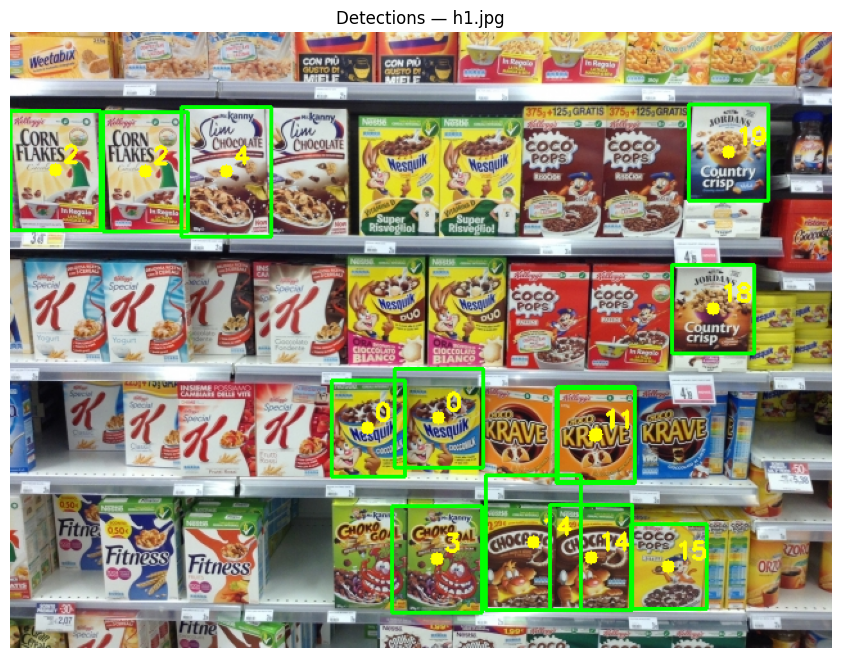

=========== h2.jpg: 20 detection(s) ===========


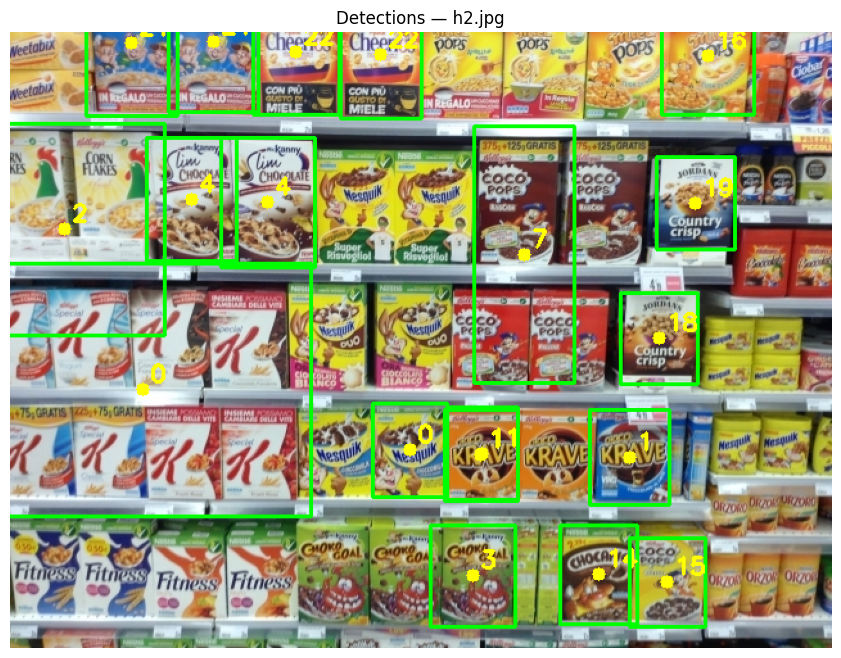

=========== h3.jpg: 12 detection(s) ===========


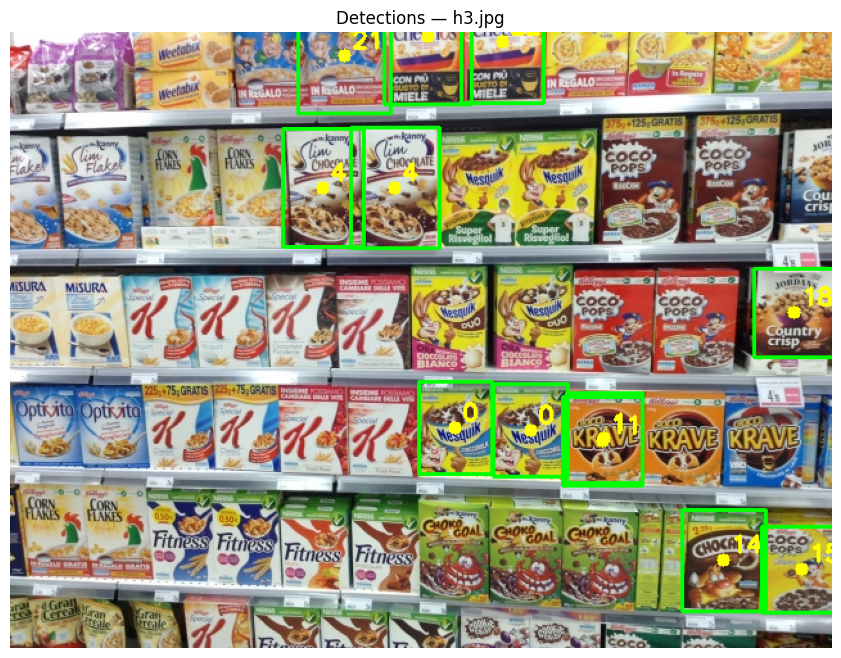

=========== h4.jpg: 20 detection(s) ===========


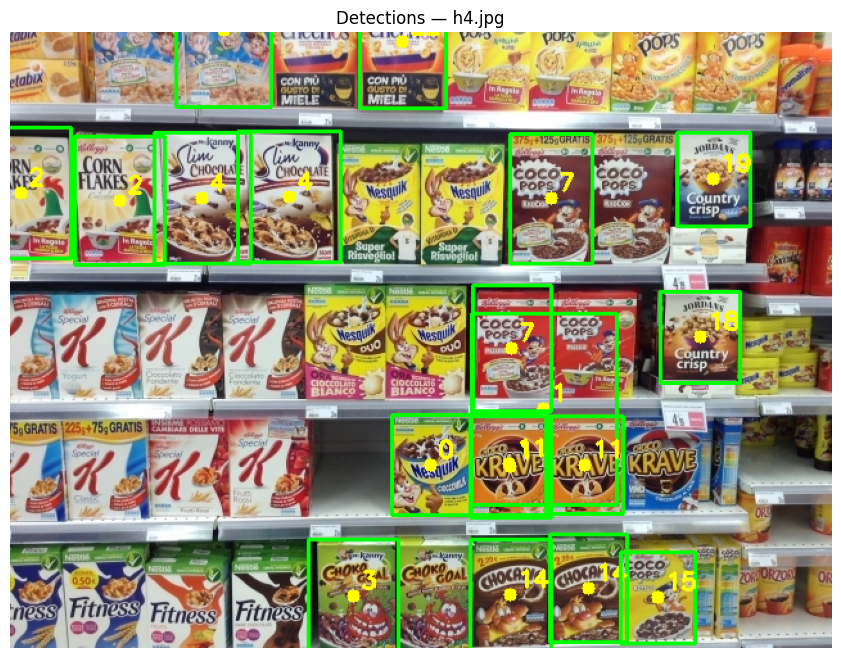

=========== h5.jpg: 25 detection(s) ===========


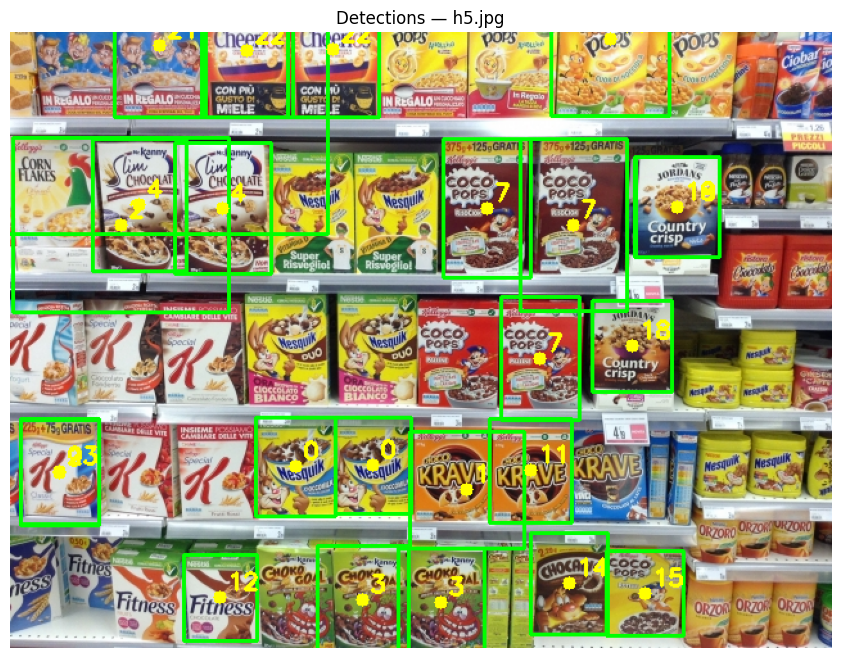

In [13]:
# Load all 24 model images once
models = {pid: cv2.imread(str(MODELS_DIR / f"{pid}.jpg"), cv2.IMREAD_COLOR)
          for pid in STEP_C_PRODUCTS}

all_detections = {}

for scene_name in STEP_C_SCENES:
    sid = scene_name.replace(".png", "")
    scene_bgr = cv2.imread(str(SCENES_DIR / scene_name), cv2.IMREAD_COLOR)
    scene_gray = cv2.cvtColor(scene_bgr, cv2.COLOR_BGR2GRAY)

    # Scene SIFT computed once and shared across every product check
    sift_scene = cv2.SIFT_create(contrastThreshold=SIFT_CONTRAST_THRESHOLD)
    kp_scene, des_scene = sift_scene.detectAndCompute(scene_gray, None)

    detections = []
    for pid, model_bgr in models.items():
        detections.extend(
            detect_instances(model_bgr, scene_bgr, scene_gray, kp_scene, des_scene, pid)
        )
    all_detections[sid] = detections

    print(f"=========== {sid}: {len(detections)} detection(s) ===========")

    # All bboxes for this scene on one image
    scene_with_dets = scene_bgr.copy()
    for d in detections:
        cx, cy = d["center"]
        x0, y0 = cx - d["width"] // 2, cy - d["height"] // 2
        cv2.rectangle(scene_with_dets, (x0, y0),
                      (x0 + d["width"], y0 + d["height"]), (0, 255, 0), 2)
        cv2.circle(scene_with_dets, (cx, cy), 5, (0, 255, 255), -1)
        cv2.putText(scene_with_dets, d["model_id"], (cx + 6, cy - 6),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)
    show_bgr(scene_with_dets, title=f"Detections — {sid}")

# Final report

Per-scene summary in the project's spec format.

In [ ]:
for sid in sorted(all_detections.keys()):
    dets = all_detections[sid]
    print(f"========== {sid} ==========")

    by_pid = {}
    for d in dets:
        by_pid.setdefault(d["model_id"], []).append(d)

    for pid in sorted(by_pid.keys(), key=lambda s: int(s)):
        instances = by_pid[pid]
        print(f"Product {pid} - {len(instances)} instance found:")
        for i, d in enumerate(instances, start=1):
            print(f"\tInstance {i} {{position: ({d['center'][0]},{d['center'][1]}), "
                  f"width: {d['width']}px, height: {d['height']}px}}")
    print()